# 👁️ TP 2 : CNN pour la reconnaissance de chiffres

**Durée indicative : 2 h 30 — Le jeu `digits` est embarqué dans Scikit-Learn et fonctionne hors ligne.**

## Objectifs observables

1. appliquer un filtre de Sobel à une image ;
2. suivre les formes `(B, C, H, W)` dans deux blocs convolutifs ;
3. entraîner un CNN sur un train et mesurer l'exactitude sur un test séparé ;
4. visualiser des cartes d'activation sans leur attribuer automatiquement une sémantique.


## 1. Imports et Configuration de l'Accélérateur


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cpu')  # Suffisant et stable pour ce petit jeu.
print(f"Dispositif de calcul utilisé : {device}")


Dispositif de calcul utilisé : cpu


## 2. Intuition Visuelle : L'Opération de Convolution 2D

Avant d'entraîner un modèle, comprenons ce qu'est un **filtre de convolution**. Appliquons manuellement un filtre de Sobel (détecteur de contours verticaux) sur un motif synthétique.


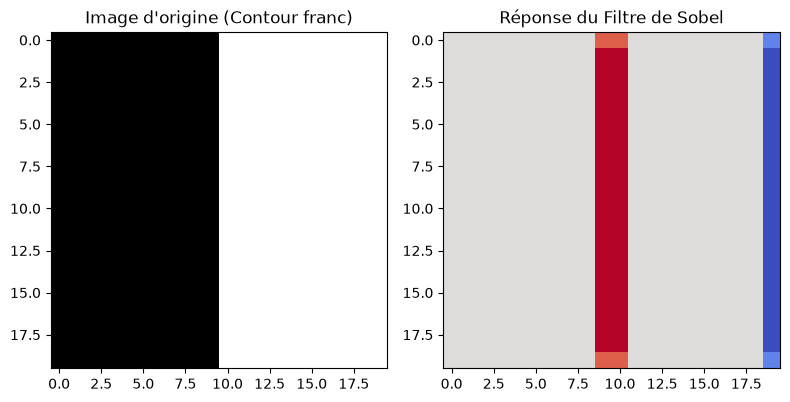

In [2]:
# Création d'une image synthétique 20x20 avec une bande verticale
img_sample = np.zeros((20, 20))
img_sample[:, 10:] = 1.0

# Noyau de Sobel vertical 3x3
sobel_kernel = torch.tensor([
    [-1.0, 0.0, 1.0],
    [-2.0, 0.0, 2.0],
    [-1.0, 0.0, 1.0]
]).unsqueeze(0).unsqueeze(0) # Forme: (out_channels=1, in_channels=1, H=3, W=3)

img_tensor = torch.tensor(img_sample, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
filtered = F.conv2d(img_tensor, sobel_kernel, padding=1)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_sample, cmap='gray')
axes[0].set_title("Image d'origine (Contour franc)")
axes[1].imshow(filtered.squeeze().numpy(), cmap='coolwarm')
axes[1].set_title("Réponse du Filtre de Sobel")
plt.tight_layout()
plt.show()


Le filtre réagit à la frontière verticale. Dans un CNN entraîné, les noyaux sont ajustés par rétropropagation ; une carte fortement activée signale un motif utile au calcul, sans fournir à elle seule une explication sémantique.

---

## 3. Chargement du jeu `digits`

`load_digits` contient 1 797 images $8 \times 8$ de chiffres manuscrits, avec des pixels compris entre 0 et 16. Il est fourni avec Scikit-Learn : aucune connexion réseau n'est nécessaire.


In [3]:
digits = load_digits()
images_np = (digits.images.astype(np.float32) / 16.0)[:, None, :, :]
labels_np = digits.target.astype(np.int64)

X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    images_np,
    labels_np,
    test_size=0.20,
    random_state=42,
    stratify=labels_np,
)

train_dataset = TensorDataset(
    torch.tensor(X_train_img), torch.tensor(y_train_img)
)
test_dataset = TensorDataset(
    torch.tensor(X_test_img), torch.tensor(y_test_img)
)
loader_generator = torch.Generator().manual_seed(42)
train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True, generator=loader_generator
)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
classes = [str(i) for i in range(10)]

print(f"Entraînement : {len(train_dataset)} images")
print(f"Test          : {len(test_dataset)} images")
assert set(map(id, [train_dataset, test_dataset]))  # Objets distincts.


Entraînement : 1437 images
Test          : 360 images


Affichons quelques échantillons du dataset :


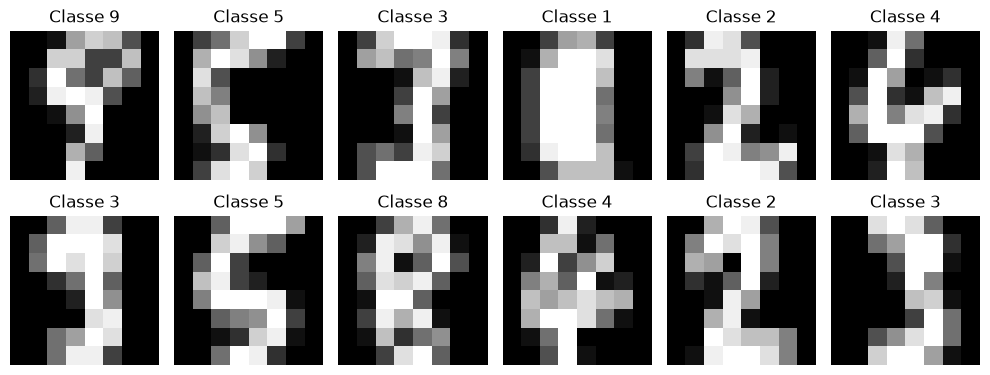

In [4]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"Classe {classes[labels[i]]}")
    ax.axis('off')
plt.tight_layout()
plt.show()


## 4. Architecture CNN et suivi des dimensions

PyTorch représente un lot d'images par `(B, C, H, W)` : taille du lot, canaux, hauteur, largeur. Ici :

$$8 \times 8 \xrightarrow{\text{pool 1}} 4 \times 4
\xrightarrow{\text{pool 2}} 2 \times 2$$

Les couches convolutives conservent la taille grâce à `padding=1`, puis chaque max-pooling la divise par deux.


In [5]:
class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 2 * 2, 64)
        self.dropout = nn.Dropout(0.20)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 8 -> 4
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 4 -> 2
        x = torch.flatten(x, start_dim=1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)


model = DigitCNN().to(device)
sample_logits = model(images[:4].to(device))
assert sample_logits.shape == (4, 10)
print(model)
print("Forme de sortie contrôlée :", tuple(sample_logits.shape))


DigitCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)
Forme de sortie contrôlée : (4, 10)


## 5. Entraînement et Évaluation du CNN


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 18
training_history = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_images, targets in train_loader:
        batch_images, targets = batch_images.to(device), targets.to(device)
        optimizer.zero_grad()
        logits = model(batch_images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_images.size(0)
        correct += (logits.argmax(dim=1) == targets).sum().item()
        total += targets.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    training_history.append((epoch_loss, epoch_accuracy))
    if epoch == 0 or (epoch + 1) % 6 == 0:
        print(
            f"Époque {epoch + 1:02d}/{epochs} — "
            f"perte {epoch_loss:.4f} — exactitude train {epoch_accuracy:.2%}"
        )


Époque 01/18 — perte 2.0650 — exactitude train 37.72%


Époque 06/18 — perte 0.1656 — exactitude train 96.59%


Époque 12/18 — perte 0.0524 — exactitude train 98.96%


Époque 18/18 — perte 0.0245 — exactitude train 99.51%


Évaluons la performance sur le jeu de test indépendant :


In [7]:
model.eval()
test_correct = 0
test_total = 0
all_predictions = []

with torch.no_grad():
    for batch_images, targets in test_loader:
        logits = model(batch_images.to(device))
        predictions = logits.argmax(dim=1).cpu()
        all_predictions.append(predictions)
        test_correct += (predictions == targets).sum().item()
        test_total += targets.size(0)

test_accuracy = test_correct / test_total
print(f"Exactitude sur le test indépendant : {test_accuracy:.2%}")
assert test_total == len(test_dataset)
assert test_accuracy >= 0.85, "Performance anormalement basse : vérifier l'exécution."


Exactitude sur le test indépendant : 98.06%


## 6. Visualisation des Cartes de Caractéristiques (Feature Maps)

Regardons ce que "voit" la première couche de convolution lorsqu'on lui présente une image.


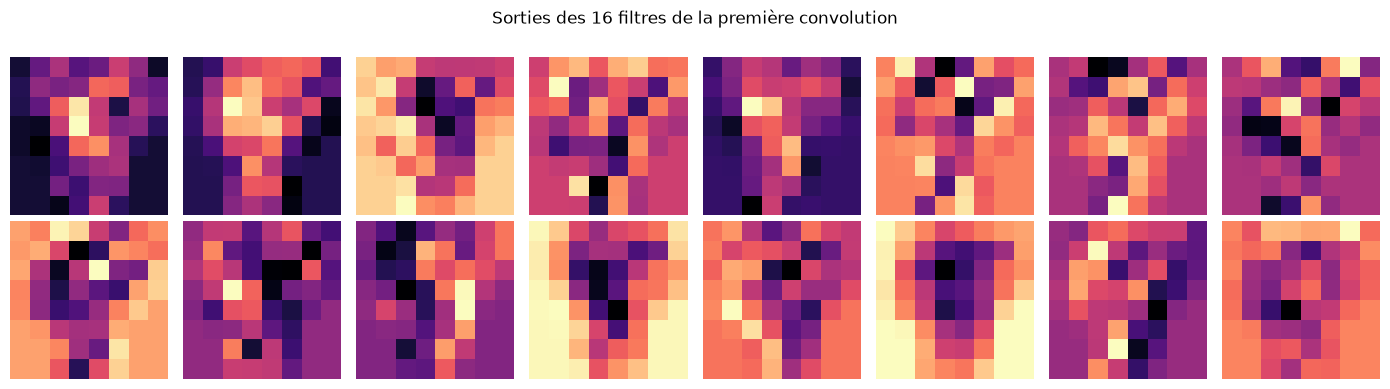

In [8]:
model.eval()
sample_img = images[0:1].to(device)

with torch.no_grad():
    feature_maps = model.conv1(sample_img).squeeze(0).cpu()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for index, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[index], cmap='magma')
    ax.axis('off')
plt.suptitle("Sorties des 16 filtres de la première convolution")
plt.tight_layout()
plt.show()


## 7. Exercice guidé : ajouter un troisième bloc

Ajoutez un bloc `32 -> 64` suivi d'un pooling. La taille spatiale passe alors de $2 \times 2$ à $1 \times 1$. Utilisez `nn.Flatten()` puis une couche dense adaptée.

**Critère de réussite** : pour un lot de quatre images, la sortie doit avoir la forme `(4, 10)`. Ce contrôle valide les dimensions, pas la qualité prédictive du modèle non entraîné.


In [9]:
# À vous de jouer.
# TODO : définir une architecture à trois blocs puis contrôler sa sortie.


In [10]:
class DeeperDigitCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 1 * 1, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


deeper_model = DeeperDigitCNN().to(device)
deeper_logits = deeper_model(images[:4].to(device))
assert deeper_logits.shape == (4, 10)
print("Forme obtenue :", tuple(deeper_logits.shape))
print(f"Nombre de paramètres : {sum(p.numel() for p in deeper_model.parameters()):,}")


Forme obtenue : (4, 10)
Nombre de paramètres : 25,706


## Conclusion et auto-évaluation

1. Les convolutions partagent des poids et exploitent des voisinages locaux.
2. Les formes des tenseurs sont contrôlées avant l'entraînement.
3. L'exactitude annoncée provient du test séparé, pas du train.
4. Les cartes d'activation montrent des réponses numériques ; une interprétation sémantique demande des analyses supplémentaires.
